# 06 — Supervised Balanced Random Forest

This notebook:
- loads the prepared train, validation, and test splits,
- trains the binary Balanced Random Forest model,
- evaluates validation and test performance,
- plots feature importance,
- compares SBS96 importance with the COSMIC SBS4 profile.


In [65]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
)
from sklearn.metrics.pairwise import cosine_similarity
from imblearn.ensemble import BalancedRandomForestClassifier

PROJECT_ROOT = Path.cwd().resolve()

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)

## 1. Define paths


In [66]:
split_output_dir = PROJECT_ROOT / "data" / "brf_split_binary"
plot_dir = PROJECT_ROOT / "plots" / "brf_split_binary"
cosmic_sbs4_path = PROJECT_ROOT / "data" / "v3.2_SBS4_DIFFERENCE.txt"

plot_dir.mkdir(parents=True, exist_ok=True)

train_path = split_output_dir / "train.csv"
val_path = split_output_dir / "val.csv"
test_path = split_output_dir / "test.csv"

## 2. Load the split tables


In [67]:
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

sbs_cols = [
    col for col in train_df.columns
    if "[" in str(col) and ">" in str(col) and "]" in str(col)
]


print(f'Number of mutation channels: {len(sbs_cols)}\n')

pd.DataFrame({
    "table": ["train", "validation", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "columns": [train_df.shape[1], val_df.shape[1], test_df.shape[1]],
})

Number of mutation channels: 96



,table,rows,columns
0,train,315,105
1,validation,79,105
2,test,99,105


In [68]:
train_df.head()

,Patient_ID,exposures.tobacco_smoking_status,exposures.pack_years_smoked,demographic.age_at_index,demographic.gender,demographic.race,demographic.ethnicity,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,A[C>G]A,A[C>G]C,A[C>G]G,A[C>G]T,A[C>T]A,A[C>T]C,A[C>T]G,A[C>T]T,A[T>A]A,A[T>A]C,A[T>A]G,A[T>A]T,A[T>C]A,A[T>C]C,A[T>C]G,A[T>C]T,A[T>G]A,A[T>G]C,A[T>G]G,A[T>G]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,C[C>G]A,C[C>G]C,C[C>G]G,C[C>G]T,C[C>T]A,C[C>T]C,C[C>T]G,C[C>T]T,C[T>A]A,C[T>A]C,C[T>A]G,C[T>A]T,C[T>C]A,C[T>C]C,C[T>C]G,C[T>C]T,C[T>G]A,C[T>G]C,C[T>G]G,C[T>G]T,G[C>A]A,G[C>A]C,G[C>A]G,G[C>A]T,G[C>G]A,G[C>G]C,G[C>G]G,G[C>G]T,G[C>T]A,G[C>T]C,G[C>T]G,G[C>T]T,G[T>A]A,G[T>A]C,G[T>A]G,G[T>A]T,G[T>C]A,G[T>C]C,G[T>C]G,G[T>C]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[C>A]A,T[C>A]C,T[C>A]G,T[C>A]T,T[C>G]A,T[C>G]C,T[C>G]G,T[C>G]T,T[C>T]A,T[C>T]C,T[C>T]G,T[C>T]T,T[T>A]A,T[T>A]C,T[T>A]G,T[T>A]T,T[T>C]A,T[T>C]C,T[T>C]G,T[T>C]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T,Smoking_3,Smoking_Bin
0,TCGA-67-3773,Current Reformed Smoker for > 15 yrs,NaN,84.0,female,white,not hispanic or latino,3.0,5.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,3.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,7.0,5.0,3.0,3.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,4.0,3.0,0.0,0.0,0.0,0.0,3.0,2.0,3.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0,4.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,Former,1
1,TCGA-NJ-A7XG,Current Reformed Smoker for > 15 yrs,NaN,49.0,male,black or african american,not hispanic or latino,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Former,1
2,TCGA-91-6848,Current Reformed Smoker for < or = 15 yrs,NaN,59.0,male,white,not hispanic or latino,11.0,12.0,9.0,5.0,4.0,6.0,5.0,6.0,9.0,4.0,4.0,8.0,1.0,3.0,2.0,0.0,10.0,2.0,7.0,3.0,1.0,2.0,2.0,1.0,26.0,23.0,12.0,29.0,7.0,8.0,4.0,7.0,9.0,10.0,8.0,14.0,0.0,3.0,12.0,3.0,4.0,4.0,6.0,3.0,0.0,2.0,7.0,1.0,14.0,17.0,5.0,5.0,8.0,4.0,5.0,4.0,6.0,6.0,2.0,5.0,2.0,3.0,3.0,2.0,7.0,2.0,2.0,7.0,0.0,0.0,1.0,0.0,12.0,24.0,5.0,16.0,19.0,2.0,3.0,21.0,22.0,10.0,6.0,14.0,1.0,2.0,5.0,0.0,3.0,3.0,2.0,0.0,0.0,0.0,3.0,1.0,Former,1
3,TCGA-55-6986,Lifelong Non-Smoker,NaN,74.0,female,white,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Never,0
4,TCGA-73-4677,Current Reformed Smoker for > 15 yrs,NaN,74.0,male,white,not hispanic or latino,12.0,10.0,0.0,4.0,2.0,5.0,1.0,2.0,2.0,2.0,5.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,18.0,15.0,1.0,11.0,2.0,1.0,0.0,2.0,5.0,4.0,6.0,8.0,1.0,1.0,4.0,0.0,1.0,2.0,4.0,0.0,0.0,0.0,0.0,2.0,9.0,11.0,3.0,7.0,0.0,1.0,1.0,2.0,7.0,5.0,1.0,4.0,0.0,3.0,3.0,1.0,0.0,5.0,2.0,0.0,0.0,0.0,0.0,1.0,4.0,8.0,5.0,7.0,4.0,2.0,0.0,2.0,7.0,6.0,4.0,3.0,1.0,1.0,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Former,1


## 3. Prepare the feature matrices


In [69]:
def prepare_features_and_label(frame, sbs_cols, age_fill=None):
    frame = frame.copy()

    frame["demographic.age_at_index"] = pd.to_numeric(
        frame["demographic.age_at_index"],
        errors="coerce"
    )

    frame["demographic.gender"] = (
        frame["demographic.gender"]
        .astype(str)
        .str.lower()
        .map({"male": 1, "female": 0})
    )

    if age_fill is None:
        age_fill = frame["demographic.age_at_index"].median()

    frame["demographic.age_at_index"] = frame["demographic.age_at_index"].fillna(age_fill)

    X_sbs = frame[sbs_cols].copy()
    X_sbs = X_sbs.div(X_sbs.sum(axis=1), axis=0).fillna(0.0)

    X_clin = frame[["demographic.age_at_index", "demographic.gender"]].copy()
    X_clin = X_clin.rename(columns={"demographic.age_at_index": "age_years"})

    X = pd.concat([X_sbs, X_clin], axis=1)
    y = frame["Smoking_Bin"].astype(int)

    return X, y, age_fill

In [70]:
X_train, y_train, age_fill = prepare_features_and_label(train_df, sbs_cols)
X_val, y_val, _ = prepare_features_and_label(val_df, sbs_cols, age_fill)
X_test, y_test, _ = prepare_features_and_label(test_df, sbs_cols, age_fill)

print(f'Age median used for filling missing age values: {age_fill}\n')

pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_rows": [len(X_train), len(X_val), len(X_test)],
    "n_features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
})

Age median used for filling missing age values: 66.0



,split,n_rows,n_features
0,train,315,98
1,validation,79,98
2,test,99,98


In [71]:
X_train.iloc[:5, :8]

,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,A[C>G]A,A[C>G]C,A[C>G]G,A[C>G]T
0,0.029412,0.049020,0.009804,0.019608,0.009804,0.000000,0.000000,0.000000
1,0.000000,0.030303,0.000000,0.030303,0.000000,0.000000,0.000000,0.000000
2,0.018242,0.019900,0.014925,0.008292,0.006633,0.009950,0.008292,0.009950
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.045283,0.037736,0.000000,0.015094,0.007547,0.018868,0.003774,0.007547


In [72]:
y_train.head()

0    1
1    1
2    1
3    0
4    1
Name: Smoking_Bin, dtype: int64

## 4. Hyperparameter tuning - Grid search

In [73]:
RANDOM_STATE = 42

results = []
best_score = -1.0
best_params = None
best_model = None

for n_estimators in [200, 400, 800]:
    for max_depth in [None, 10, 20, 30]:
        for max_features in ["sqrt", "log2", 0.5]:
            for min_samples_leaf in [1, 2, 5]:

                params = {
                    "n_estimators": n_estimators,
                    "max_features": max_features,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                }

                model = BalancedRandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    sampling_strategy="auto",
                    replacement=False,
                    bootstrap=True,
                    **params,
                )

                model.fit(X_train, y_train)

                val_pred = model.predict(X_val)
                val_proba = model.predict_proba(X_val)[:, 1]

                score_f1 = f1_score(y_val, val_pred, average="macro")
                score_bal = balanced_accuracy_score(y_val, val_pred)

                fpr, tpr, _ = roc_curve(y_val, val_proba)
                score_auc = auc(fpr, tpr)

                results.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "max_features": max_features,
                    "min_samples_leaf": min_samples_leaf,
                    "val_f1_macro": score_f1,
                    "val_balanced_accuracy": score_bal,
                    "val_auc": score_auc,
                })

                if score_f1 > best_score:
                    best_score = score_f1
                    best_params = params
                    best_model = model

grid_df = (
    pd.DataFrame(results)
    .sort_values("val_f1_macro", ascending=False)
    .reset_index(drop=True)
)

display(grid_df)

print(f'Best validation macro F1: {best_score}')
print('Best hyperparameters:')
pd.DataFrame([best_params])


,n_estimators,max_depth,max_features,min_samples_leaf,val_f1_macro,val_balanced_accuracy,val_auc
0,200,NaN,0.5,5,0.753125,0.835561,0.872995
1,200,30.0,0.5,5,0.753125,0.835561,0.872995
2,200,20.0,0.5,5,0.753125,0.835561,0.872995
3,200,10.0,0.5,5,0.753125,0.835561,0.872995
4,800,NaN,0.5,5,0.753125,0.835561,0.859626
5,800,10.0,0.5,5,0.753125,0.835561,0.859626
6,800,30.0,0.5,5,0.753125,0.835561,0.859626
7,800,20.0,0.5,5,0.753125,0.835561,0.859626
8,200,20.0,0.5,2,0.739141,0.828209,0.847594
9,200,10.0,0.5,2,0.739141,0.828209,0.847594


Best validation macro F1: 0.753125
Best hyperparameters:


,n_estimators,max_features,max_depth,min_samples_leaf
0,200,0.5,None,5


## 5. Define evaluation helpers


In [74]:
def save_report_and_cm_binary(y_true, y_pred, tag):
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    support = len(y_true)

    report_text = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Never", "Ever"],
        zero_division=0,
    )

    report_path = split_output_dir / f"{tag}_report.txt"
    with open(report_path, "w", encoding="utf-8") as handle:
        handle.write(f"accuracy: {accuracy:.4f}\n")
        handle.write(f"balanced_accuracy: {balanced_acc:.4f}\n")
        handle.write(f"f1_macro: {f1_macro:.4f}\n")
        handle.write(f"support: {support}\n\n")
        handle.write(report_text)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Never", "Ever"],
        yticklabels=["Never", "Ever"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{tag} confusion matrix")
    plt.tight_layout()

    plt.savefig(plot_dir / f"{tag}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "f1_macro": f1_macro,
        "support": support,
    }


def plot_binary_roc(y_true, y_score, tag):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curve on the {tag} set")
    plt.legend(loc="lower right")
    plt.tight_layout()

    plt.savefig(plot_dir / f"{tag}_roc.png", dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "auc": roc_auc,
    }


def evaluate_model(model, X, y, tag):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]

    metrics = save_report_and_cm_binary(y, pred, tag)
    roc_info = plot_binary_roc(y, proba, tag)

    return pd.DataFrame([{**metrics, **roc_info}])

## 6. Training-set sanity check


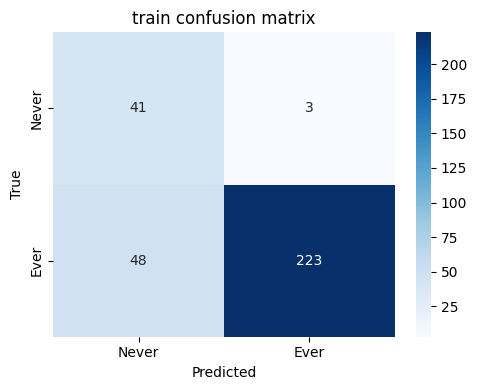

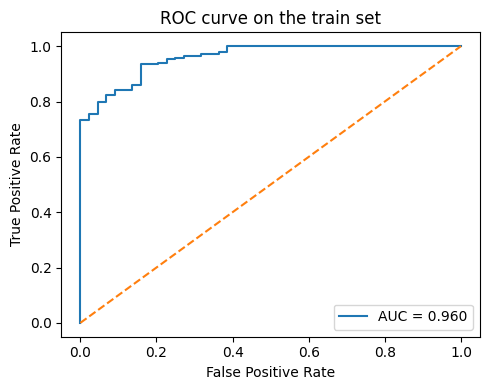

,accuracy,balanced_accuracy,f1_macro,support,auc
0,0.838095,0.877348,0.756963,315,0.959577


In [75]:
brf_selected = best_model

display(evaluate_model(brf_selected, X_train, y_train, "train"))

## 7. Validation-set evaluation


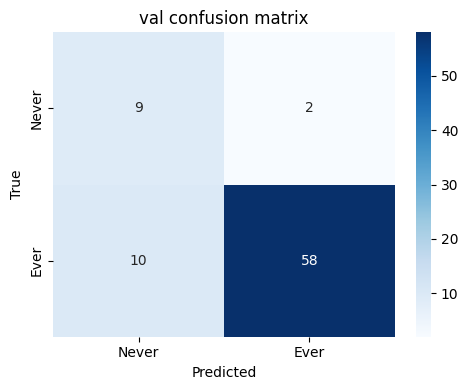

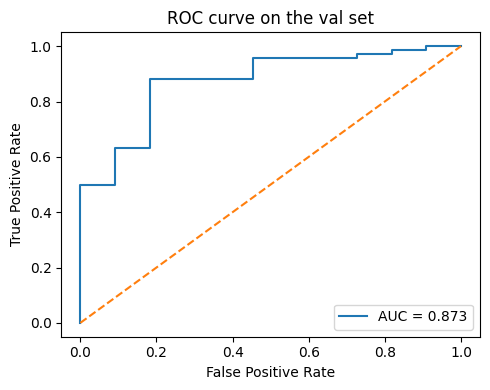

,accuracy,balanced_accuracy,f1_macro,support,auc
0,0.848101,0.835561,0.753125,79,0.872995


In [76]:
display(evaluate_model(brf_selected, X_val, y_val, "val"))

## 8. Train the final model on train + validation and evaluate the test set


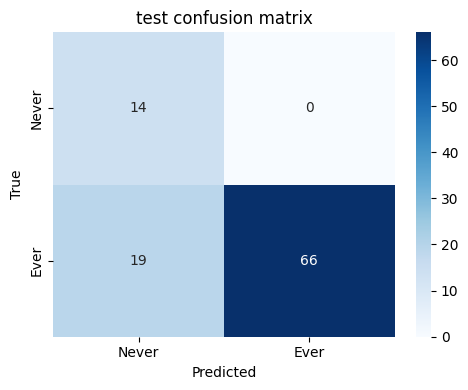

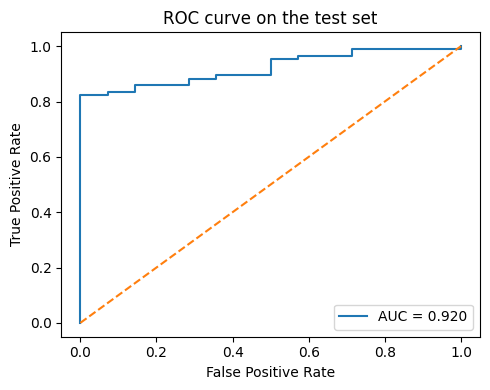

,accuracy,balanced_accuracy,f1_macro,support,auc
0,0.808081,0.888235,0.734958,99,0.920168


In [77]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

brf_final = BalancedRandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs= -1,
    sampling_strategy="auto",
    replacement=False,
    bootstrap=True,
    **best_params,
)

brf_final.fit(X_trainval, y_trainval)

evaluate_model(brf_final, X_test, y_test, "test")

## 9. Plot permutation importance


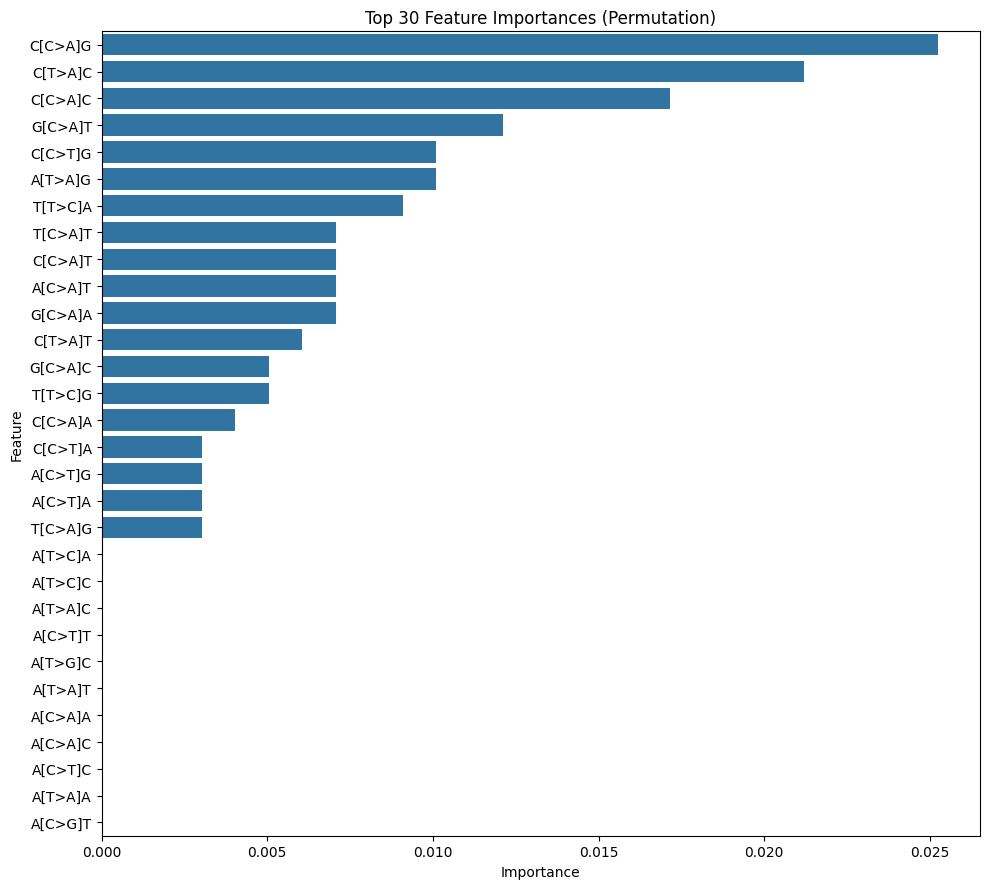

,feature,importance
0,C[C>A]G,0.025253
1,C[T>A]C,0.021212
2,C[C>A]C,0.017172
3,G[C>A]T,0.012121
4,C[C>T]G,0.010101
5,A[T>A]G,0.010101
6,T[T>C]A,0.009091
7,T[C>A]T,0.007071
8,C[C>A]T,0.007071
9,A[C>A]T,0.007071


In [78]:
perm = permutation_importance(
    brf_final,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs= -1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

perm_importance.to_csv(
    split_output_dir / "feature_importance_permutation.tsv",
    sep="\t",
    header=["importance"]
)

top30_perm = perm_importance.head(30)

plt.figure(figsize=(10, 9))
sns.barplot(x=top30_perm.values, y=top30_perm.index)

plt.title("Top 30 Feature Importances (Permutation)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

perm_path = plot_dir / "feature_importance_top30_permutation.png"
plt.savefig(perm_path, dpi=300, bbox_inches="tight")
plt.show()

display(
    top30_perm.rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

## 11. Feature importance


In [79]:
split_output_dir

PosixPath('/Users/michaljendrusak/PycharmProjects/tcga-luad-smoking-mutational-signatures/data/brf_split_binary')

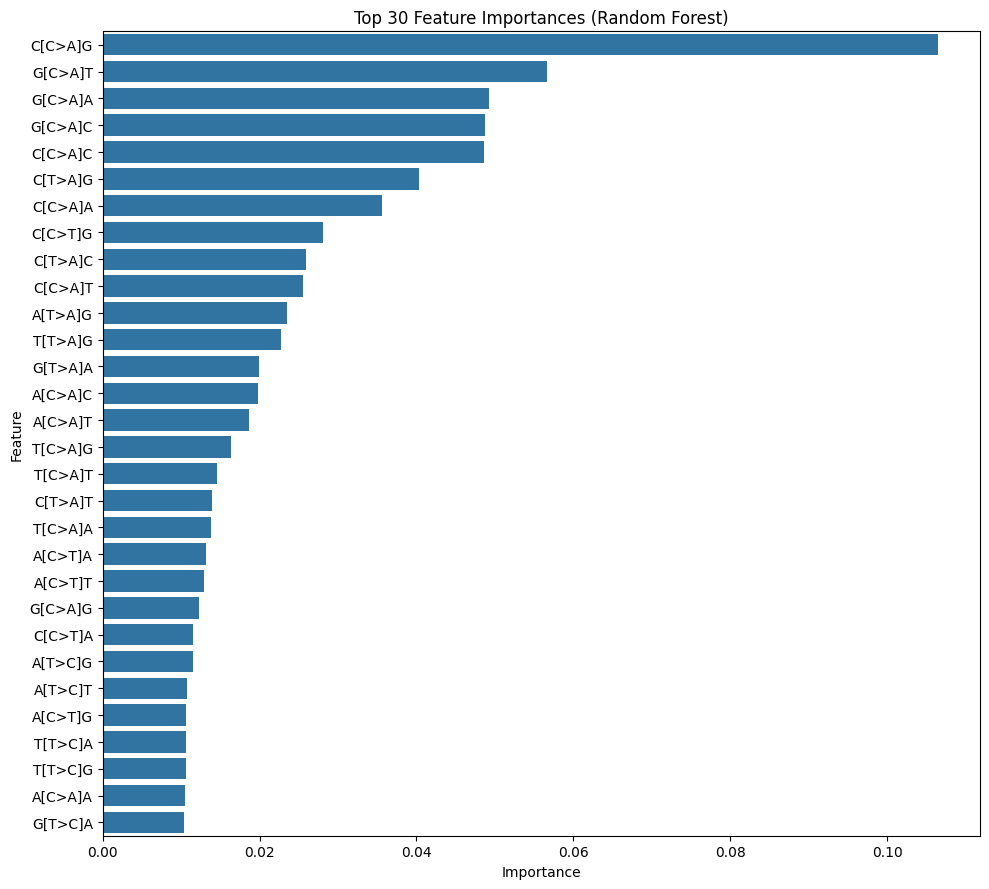

,feature,importance
0,C[C>A]G,0.106529
1,G[C>A]T,0.056684
2,G[C>A]A,0.049282
3,G[C>A]C,0.048728
4,C[C>A]C,0.048652
5,C[T>A]G,0.040361
6,C[C>A]A,0.035673
7,C[C>T]G,0.028076
8,C[T>A]C,0.025981
9,C[C>A]T,0.025564


In [80]:
fi = pd.Series(
    brf_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fi.to_csv(
    split_output_dir / "feature_importance_final_model.tsv",
    sep="\t",
    header=["importance"]
)

top30 = fi.head(30)

plt.figure(figsize=(10, 9))
sns.barplot(x=top30.values, y=top30.index)

plt.title("Top 30 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

fi_path = plot_dir / "feature_importance_top30_final.png"
plt.savefig(fi_path, dpi=300, bbox_inches="tight")
plt.show()

display(
    top30.rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

## 12. Compare the SBS96 importance profile with COSMIC SBS4


In [81]:
cosmic = pd.read_csv(cosmic_sbs4_path, sep="\t", index_col=0)

if "Signature_4_GRCh38" not in cosmic.columns:
    raise KeyError("Column 'Signature_4_GRCh38' is missing in the COSMIC SBS4 file.")

cosmic_sbs4 = cosmic["Signature_4_GRCh38"].copy()
cosmic_sbs4.index = cosmic_sbs4.index.astype(str)
cosmic_sbs4 = cosmic_sbs4.reindex(sbs_cols)

if cosmic_sbs4.isna().any():
    missing_channels = cosmic_sbs4[cosmic_sbs4.isna()].index.tolist()
    raise RuntimeError(f"Missing SBS4 values for channels: {missing_channels}")

sbs4_vec = pd.to_numeric(cosmic_sbs4, errors="coerce").astype(float)
sbs4_vec = sbs4_vec / sbs4_vec.sum()
sbs4_vec

A[C>A]A    0.036696
A[C>A]C    0.030595
A[C>A]G    0.018895
A[C>A]T    0.024420
A[C>G]A    0.009752
A[C>G]C    0.005347
A[C>G]G    0.003201
A[C>G]T    0.005427
A[C>T]A    0.012064
A[C>T]C    0.007426
A[C>T]G    0.002891
A[C>T]T    0.005929
A[T>A]A    0.004782
A[T>A]C    0.003915
A[T>A]G    0.009966
A[T>A]T    0.002991
A[T>C]A    0.008368
A[T>C]C    0.002007
A[T>C]G    0.008072
A[T>C]T    0.003590
A[T>G]A    0.000000
A[T>G]C    0.000201
A[T>G]G    0.001495
A[T>G]T    0.000199
C[C>A]A    0.045828
C[C>A]C    0.060628
C[C>A]G    0.008828
C[C>A]T    0.042946
C[C>G]A    0.010438
C[C>G]C    0.009578
C[C>G]G    0.006320
C[C>G]T    0.009345
C[C>T]A    0.020876
C[C>T]C    0.014219
C[C>T]G    0.007625
C[C>T]T    0.019982
C[T>A]A    0.007496
C[T>A]C    0.011127
C[T>A]G    0.034181
C[T>A]T    0.011569
C[T>C]A    0.005197
C[T>C]C    0.002606
C[T>C]G    0.009995
C[T>C]T    0.005432
C[T>G]A    0.000000
C[T>G]C    0.001303
C[T>G]G    0.004597
C[T>G]T    0.001207
G[C>A]A    0.037658
G[C>A]C    0.039413


In [82]:
imp_vec = fi.reindex(sbs_cols).dropna().astype(float)
imp_vec = imp_vec / imp_vec.sum()
imp_vec

A[C>A]A    0.010567
A[C>A]C    0.020067
A[C>A]G    0.010031
A[C>A]T    0.018860
A[C>G]A    0.004780
A[C>G]C    0.001517
A[C>G]G    0.002384
A[C>G]T    0.001229
A[C>T]A    0.013360
A[C>T]C    0.004119
A[C>T]G    0.010792
A[C>T]T    0.013011
A[T>A]A    0.001232
A[T>A]C    0.006906
A[T>A]G    0.023765
A[T>A]T    0.000898
A[T>C]A    0.001921
A[T>C]C    0.001494
A[T>C]G    0.011630
A[T>C]T    0.010816
A[T>G]A    0.000000
A[T>G]C    0.003067
A[T>G]G    0.000416
A[T>G]T    0.000300
C[C>A]A    0.036087
C[C>A]C    0.049217
C[C>A]G    0.107766
C[C>A]T    0.025861
C[C>G]A    0.001510
C[C>G]C    0.004124
C[C>G]G    0.008014
C[C>G]T    0.002314
C[C>T]A    0.011681
C[C>T]C    0.004383
C[C>T]G    0.028402
C[C>T]T    0.008566
C[T>A]A    0.006393
C[T>A]C    0.026283
C[T>A]G    0.040830
C[T>A]T    0.014158
C[T>C]A    0.002043
C[T>C]C    0.006570
C[T>C]G    0.008615
C[T>C]T    0.006762
C[T>G]A    0.000000
C[T>G]C    0.001492
C[T>G]G    0.009391
C[T>G]T    0.003834
G[C>A]A    0.049855
G[C>A]C    0.049294


In [83]:
TOP_N_OVERLAP = 30
top_imp = set(imp_vec.sort_values(ascending=False).head(TOP_N_OVERLAP).index)
top_sbs4 = set(sbs4_vec.sort_values(ascending=False).head(TOP_N_OVERLAP).index)
overlap = sorted(top_imp & top_sbs4)

spearman_r, spearman_p = spearmanr(imp_vec.values, sbs4_vec.values)
cos_sim = cosine_similarity(
    imp_vec.values.reshape(1, -1),
    sbs4_vec.values.reshape(1, -1),
)[0, 0]

metrics_df = pd.DataFrame([{
    "top_n": TOP_N_OVERLAP,
    "overlap_size": len(overlap),
    "spearman_r": spearman_r,
    "spearman_p": spearman_p,
    "cosine_similarity": cos_sim,
}])

metrics_df.to_csv(split_output_dir / "sbs4_overlap_metrics.tsv", sep="\t", index=False)
pd.DataFrame({"overlap_channel": overlap}).to_csv(
    split_output_dir / f"sbs4_overlap_top{TOP_N_OVERLAP}_channels.tsv",
    sep="\t",
    index=False,
)

overlap_str = '\n'.join(overlap)
print(f'Overlap channels in Top {TOP_N_OVERLAP} feature importances and SBS4 channels:\n\n{overlap_str}\n')
display(metrics_df)

Overlap channels in Top 30 feature importances and SBS4 channels:

A[C>A]A
A[C>A]C
A[C>A]T
A[C>T]A
A[T>A]G
C[C>A]A
C[C>A]C
C[C>A]T
C[C>T]A
C[T>A]C
C[T>A]G
C[T>A]T
G[C>A]A
G[C>A]C
G[C>A]G
G[C>A]T
T[C>A]A
T[C>A]G
T[C>A]T



,top_n,overlap_size,spearman_r,spearman_p,cosine_similarity
0,30,19,0.703543,1.312805e-15,0.691862


## 13. Figure creation for comparison of classifier-derived SBS96 importance with COSMIC SBS4


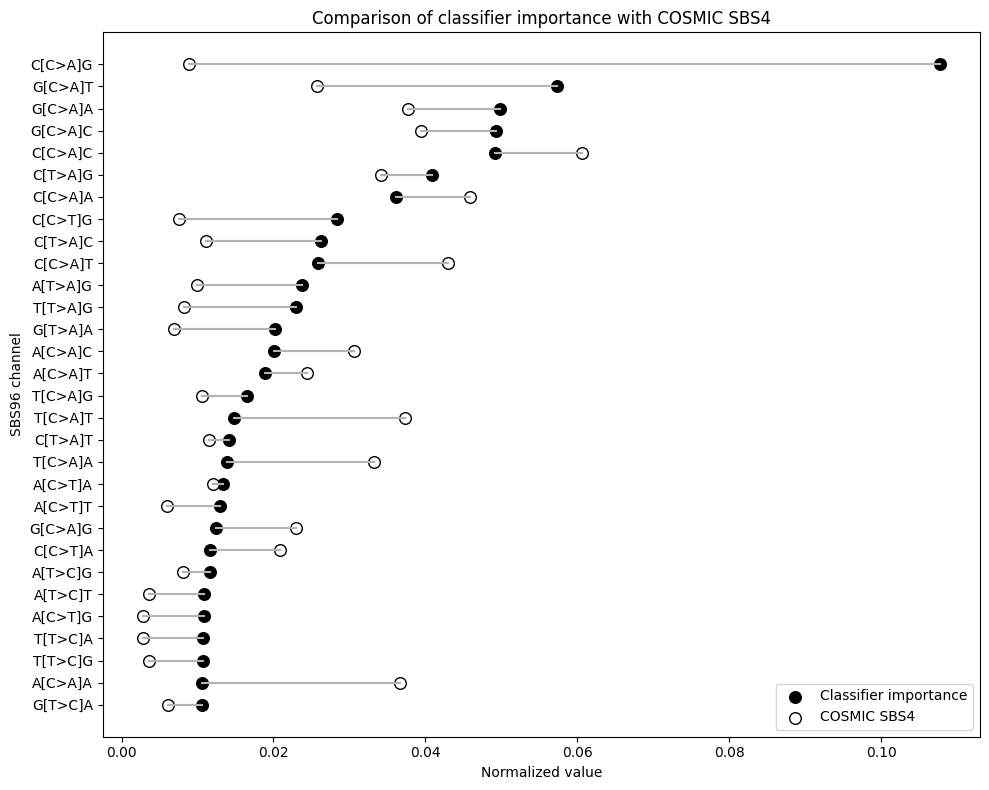

In [84]:
TOP_N = 30

top_channels = imp_vec.sort_values(ascending=False).head(TOP_N).index.tolist()

plot_df = pd.DataFrame({
    "channel": top_channels,
    "importance": imp_vec.reindex(top_channels).values,
    "sbs4": sbs4_vec.reindex(top_channels).values
})

plot_df = plot_df.sort_values("importance", ascending=True).reset_index(drop=True)

spacing = 1.4
y = np.arange(len(plot_df)) * spacing

plt.figure(figsize=(10, 8))

for i in range(len(plot_df)):
    plt.plot(
        [plot_df.loc[i, "importance"], plot_df.loc[i, "sbs4"]],
        [y[i], y[i]],
        color="0.7",
        linewidth=1.5
    )

plt.scatter(plot_df["importance"], y, s=70, color="black", label="Classifier importance")
plt.scatter(plot_df["sbs4"], y, s=70, facecolors="white", edgecolors="black", label="COSMIC SBS4")

plt.style.use('default')
plt.yticks(y, plot_df["channel"])
plt.xlabel("Normalized value")
plt.ylabel("SBS96 channel")
plt.title("Comparison of classifier importance with COSMIC SBS4")
plt.legend()
plt.tight_layout()

plt.savefig(plot_dir / "sbs4_top30_rank_comparison.png", dpi=400)

plt.show()

In [85]:
import joblib
from pathlib import Path

model_path = Path("results/balanced_random_forest_smoking_status.joblib")
model_path.parent.mkdir(exist_ok=True)

joblib.dump(brf_final, model_path)

print("Model saved to:", model_path.resolve())

Model saved to: /Users/michaljendrusak/PycharmProjects/tcga-luad-smoking-mutational-signatures/results/balanced_random_forest_smoking_status.joblib
